# Logistic Regression
- https://easy.prag-ai.com/slide/img03/1

## 분류에 사용한다. (Classification)

예) 나이대별로 이메일을 클릭해서 열지 말지를 분류해 보자.

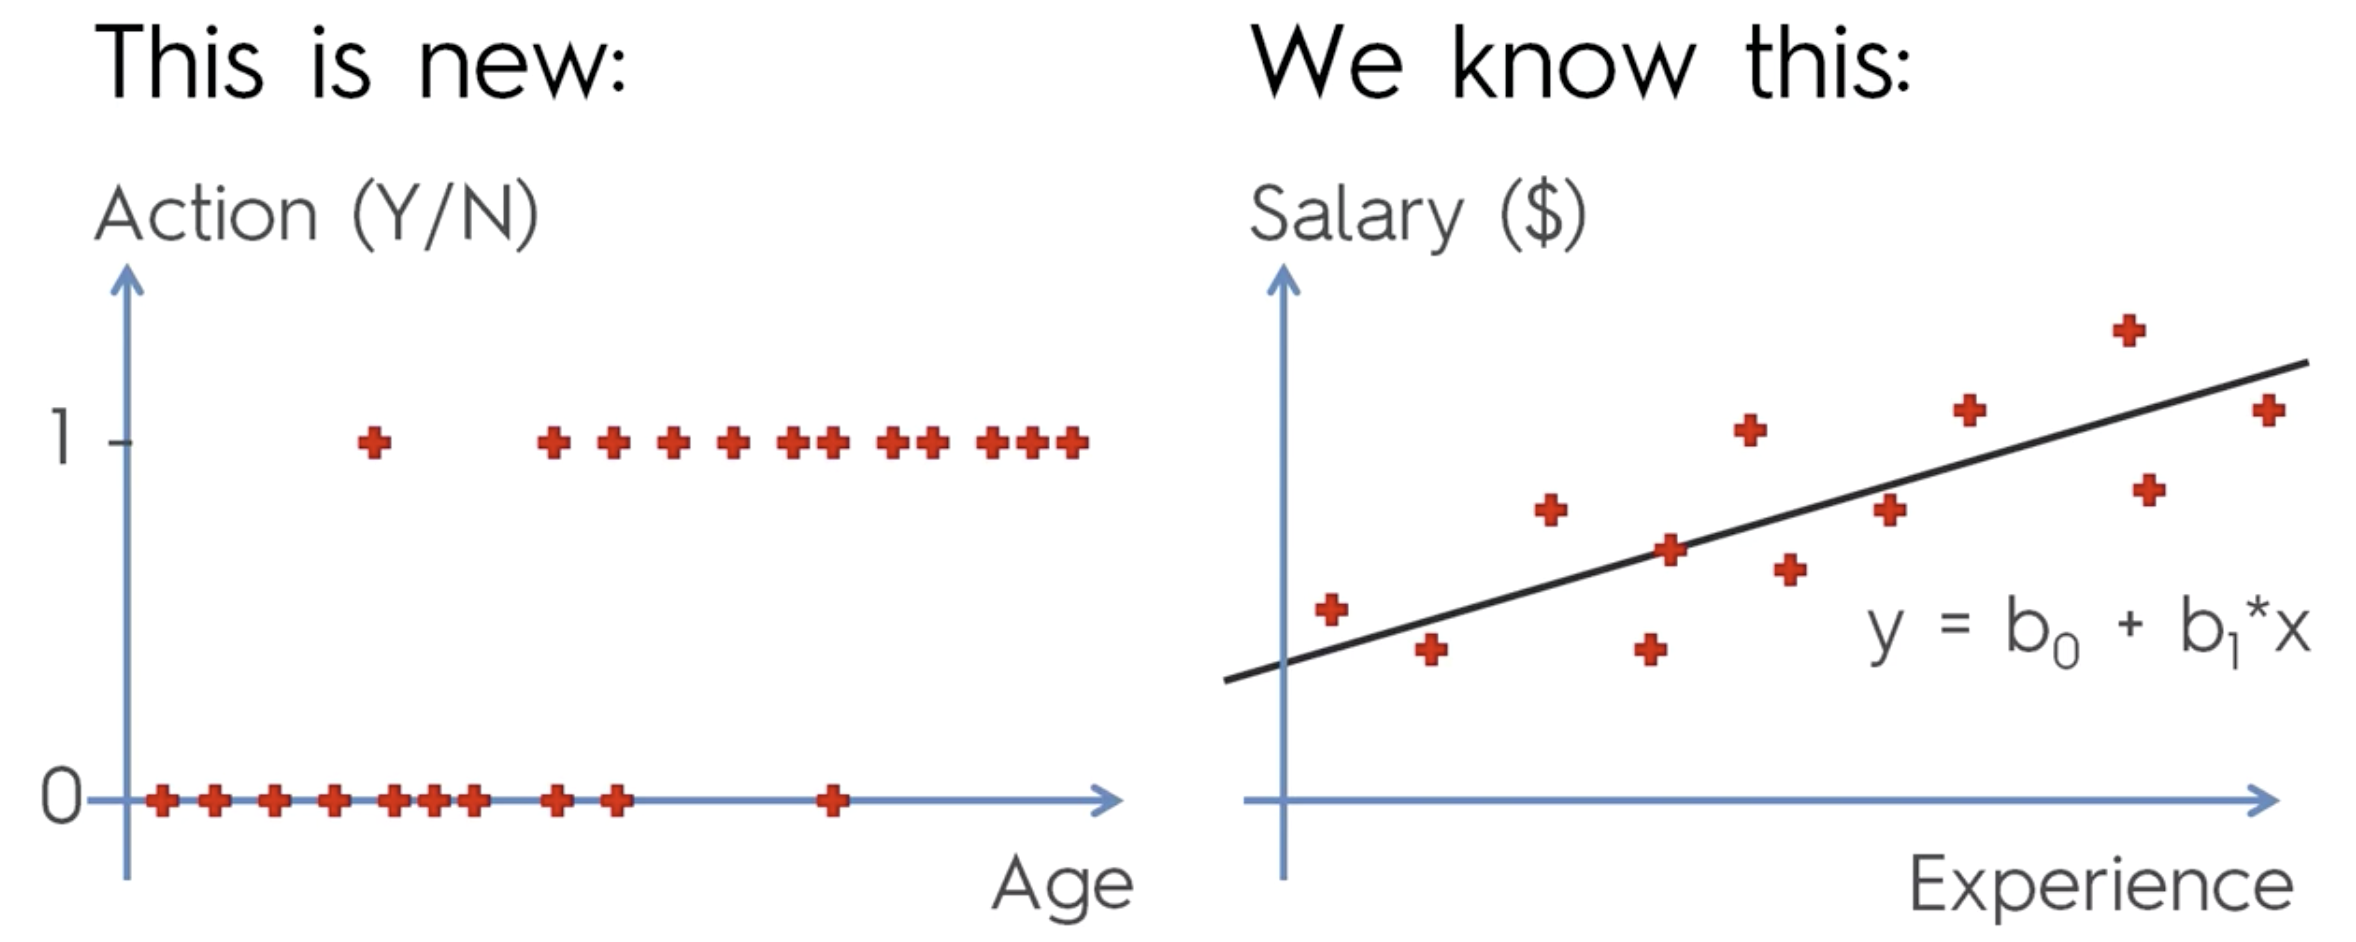

## 이메일 클릭을 할 사람과 안할 사람으로 분류할 것이다.

빨간점이 바로 데이터이며, 

액션의 0 과 1 이 바로 레이블이다. 

레이블이 있다는것은, 수퍼바이저드 러닝 이라는 뜻

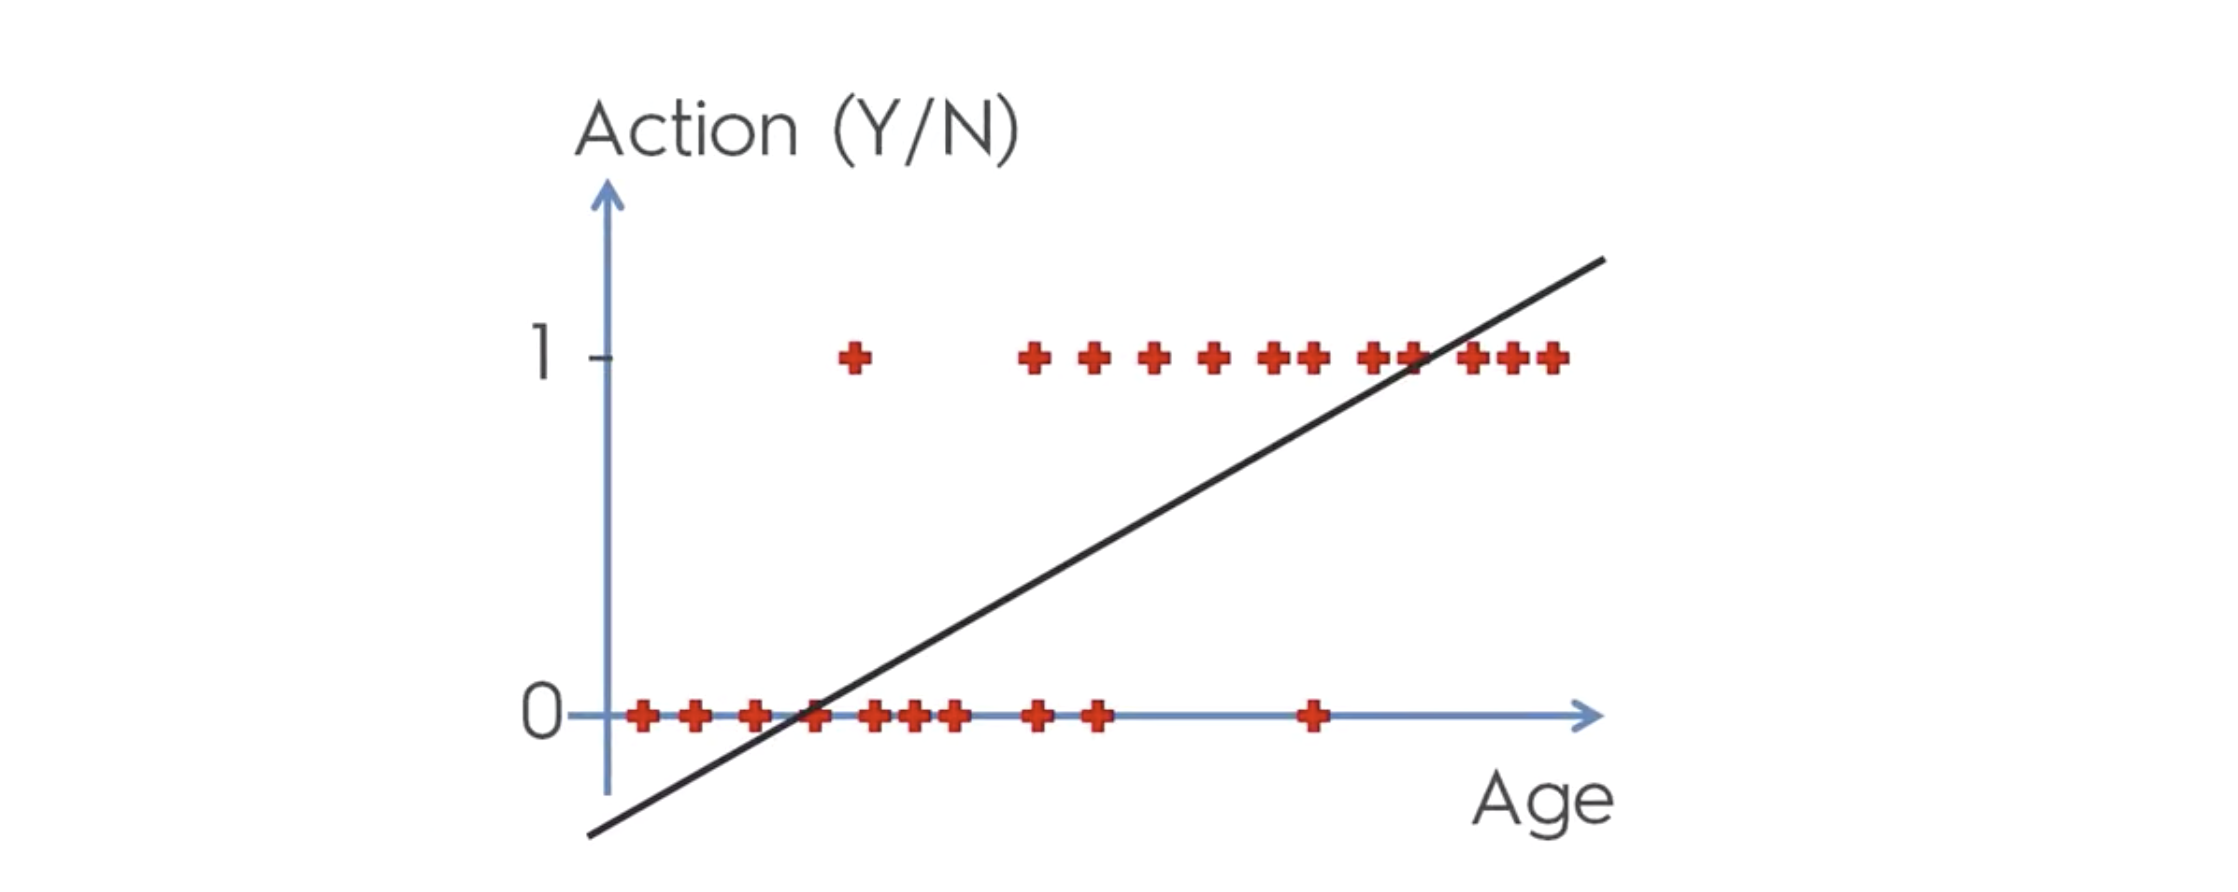

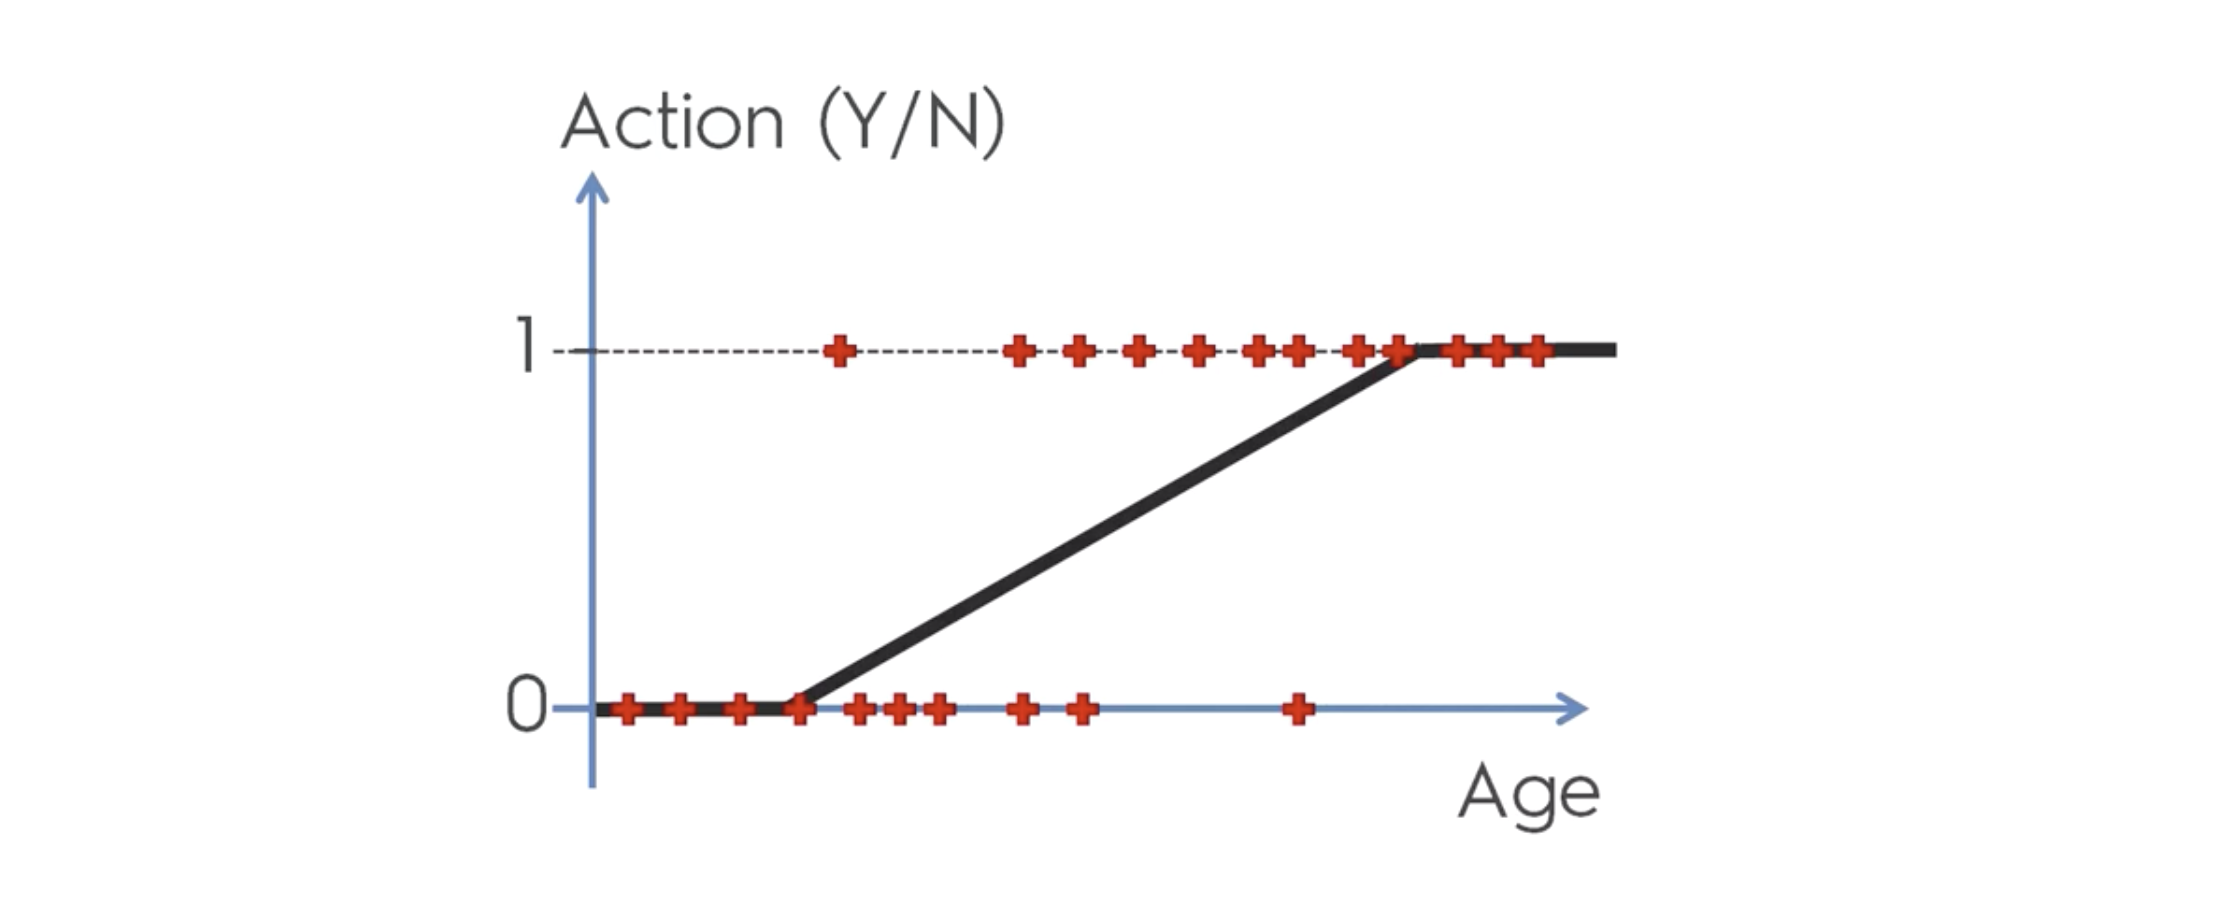

### 이렇게 비슷하게 생긴 함수가 이미존재한다. 이름은 sigmoid function

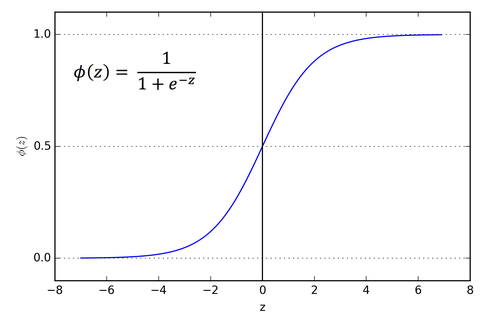

## 따라서 리니어 리그레션 식을, y 값을 시그모이드에 대입해서, 일차방정식으로 만들면 다음과 같아진다.

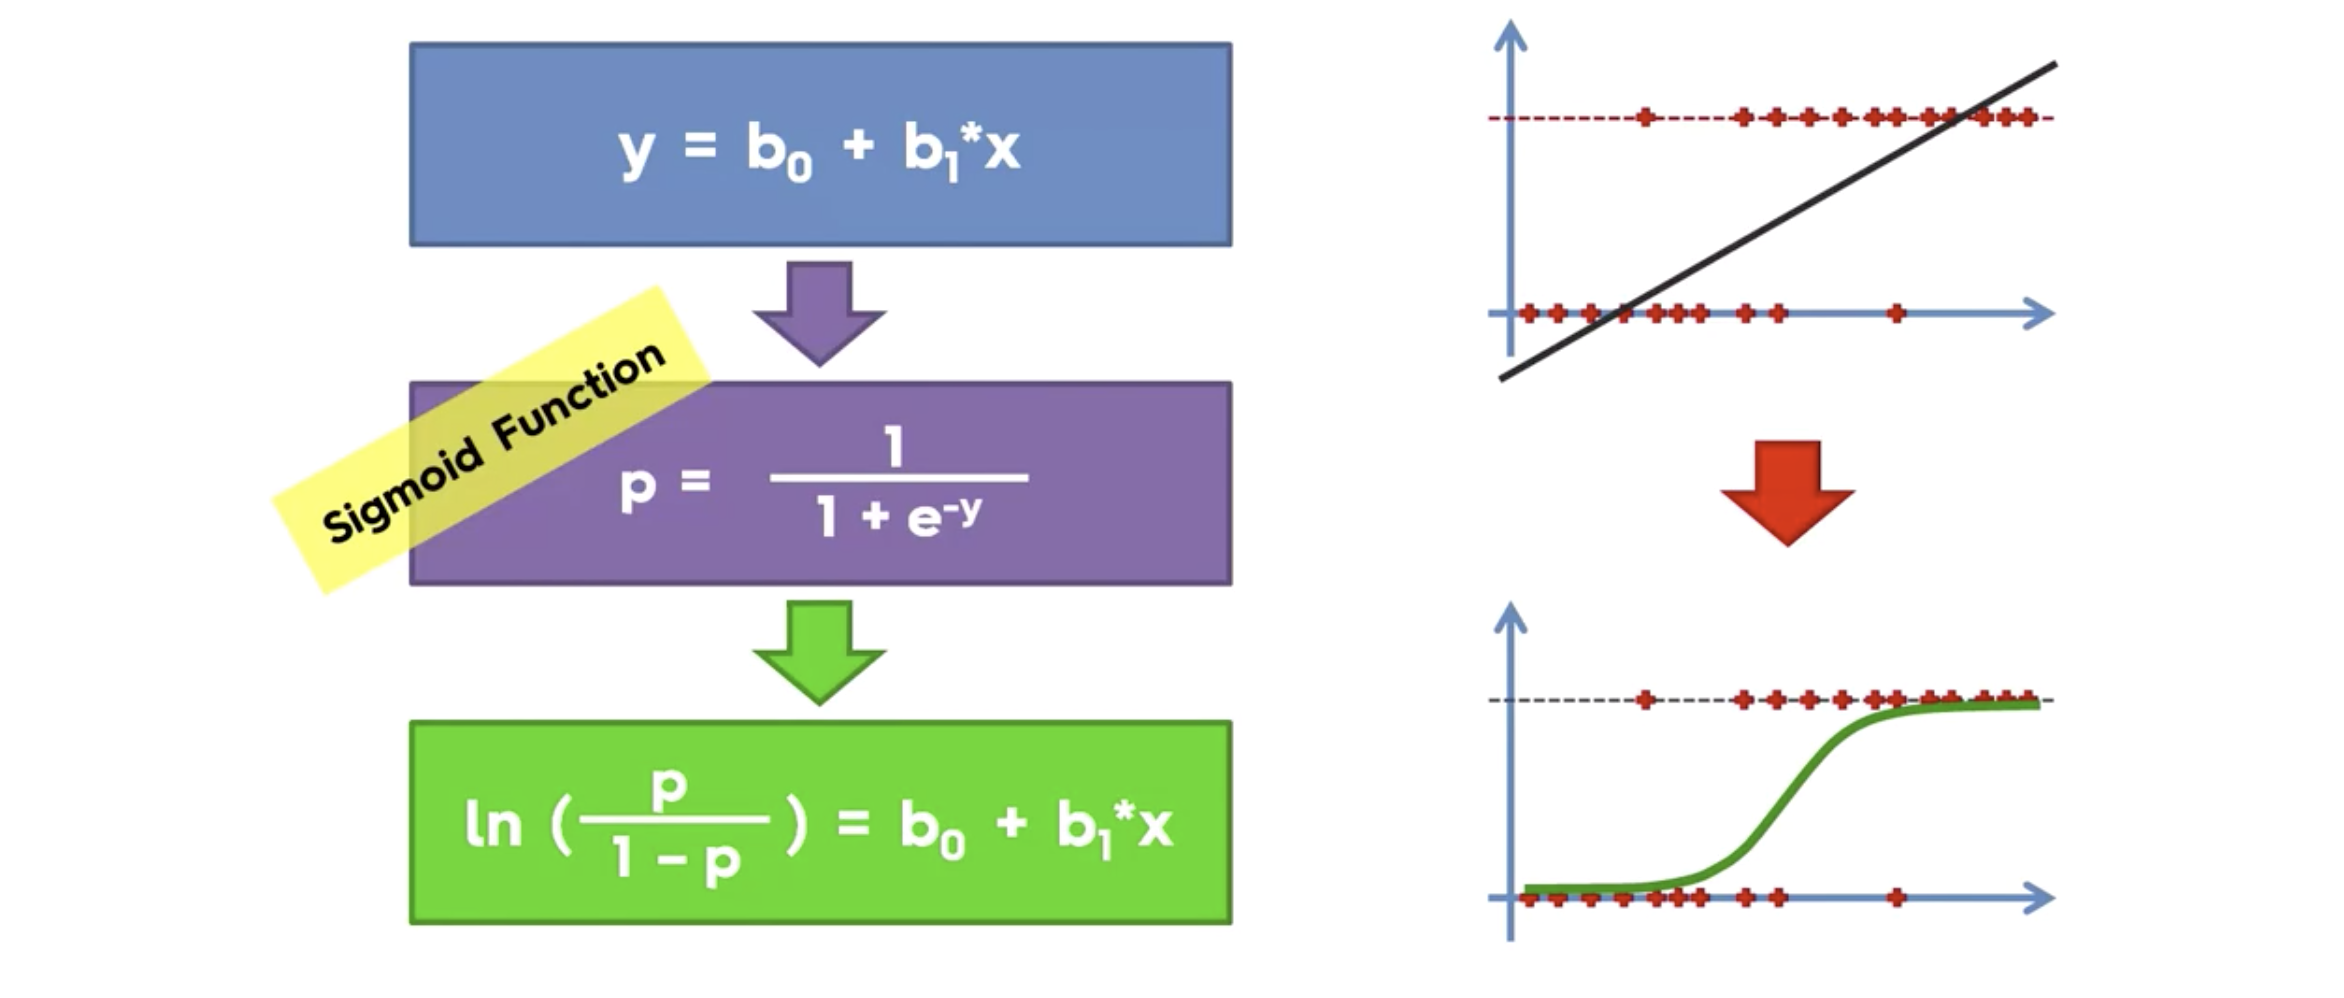

# 위와 같은 식을 가진 regression 을, Logistic Regression이라 한다.

---

## 이를 가지고 두개의 클래스로 분류할 수 있다. 
( 클릭을 한다, 안한다 두개로) 확률로 나타낼 수 있게 되었다.

p는 확률값을 나타낸다.

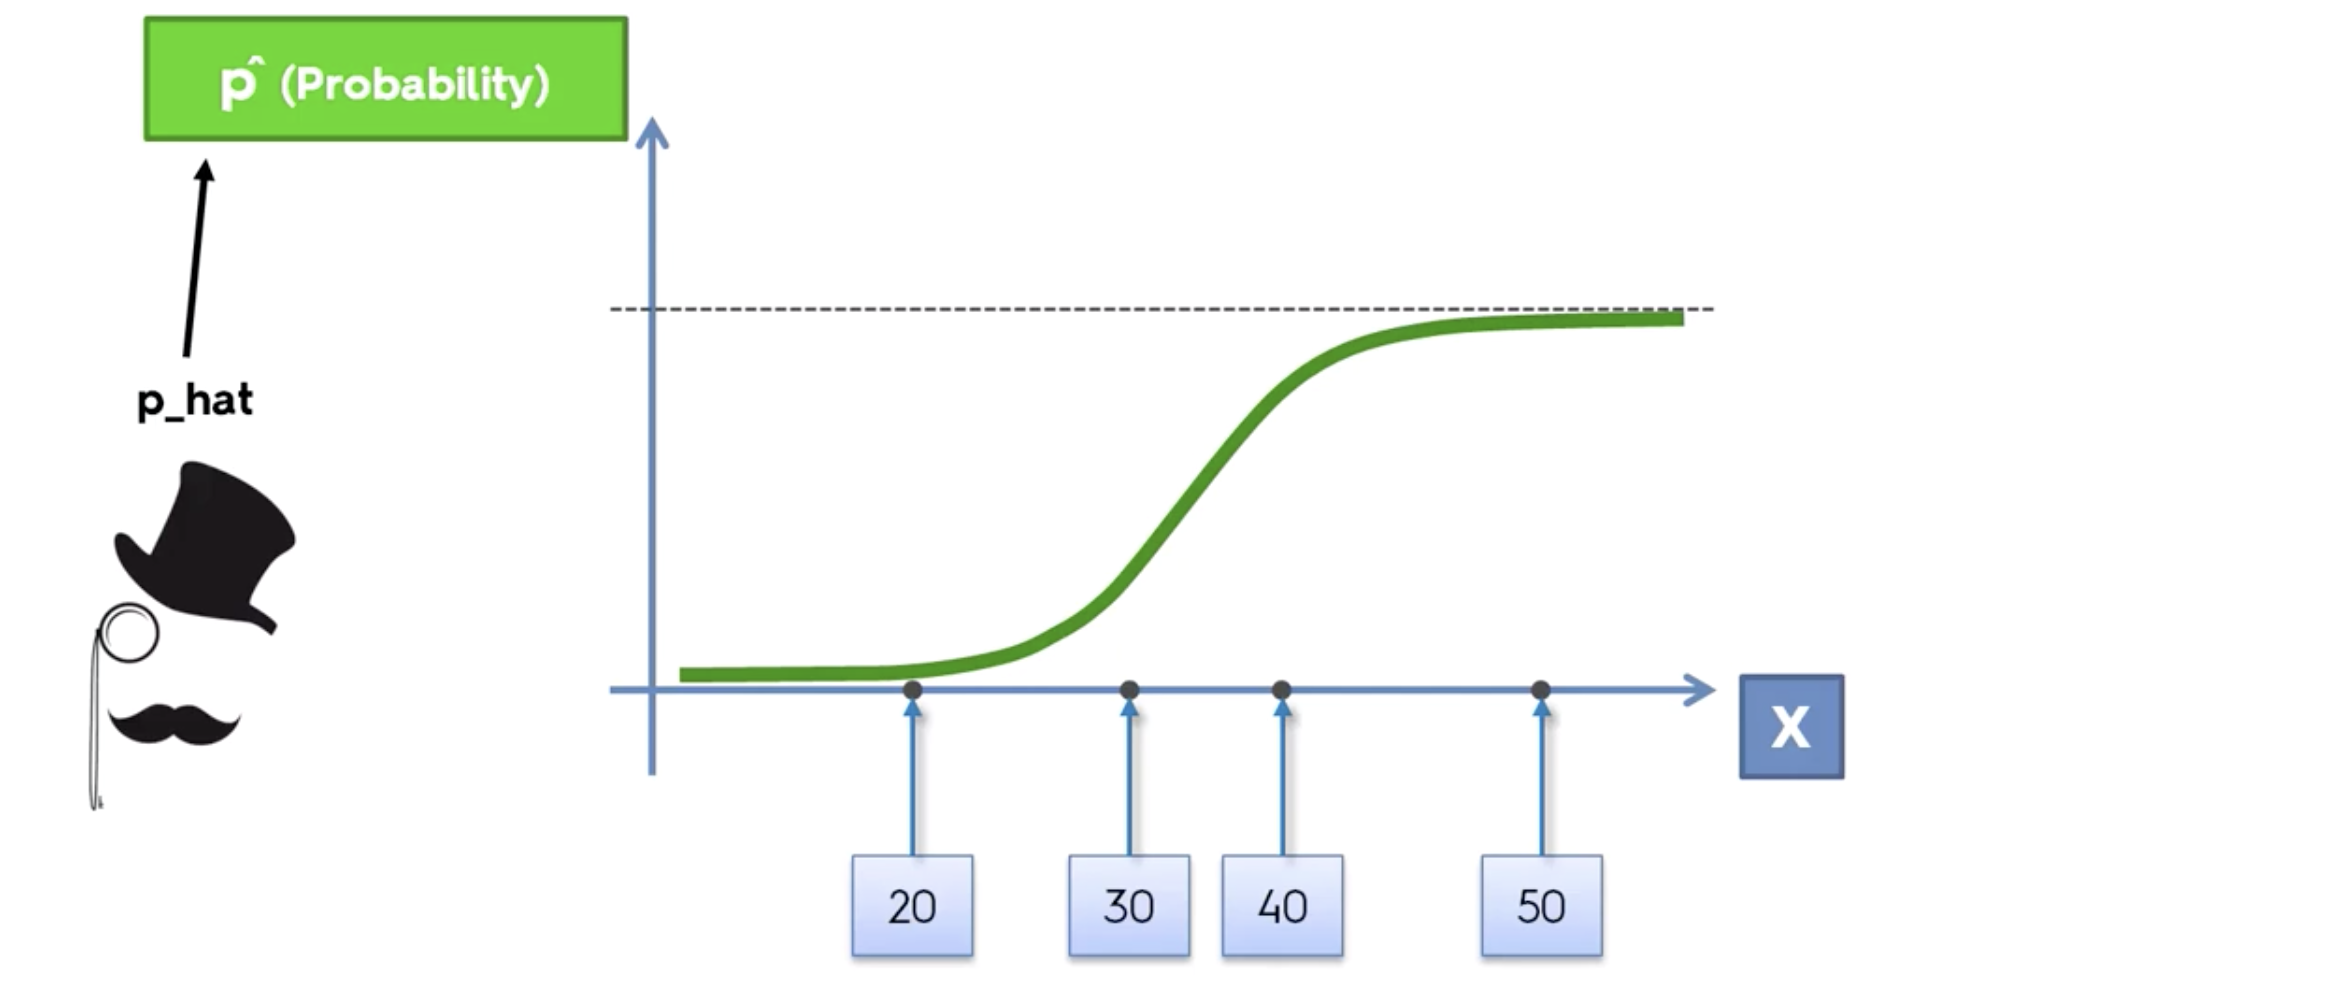

### 20대는 클릭할 확률이 0.7%,  40대는 85%, 50대는 99.4% 

이 확률값은, 위에서의 시그모이드 함수를 적용한 식을 통해 나온 값임을 기억한다.

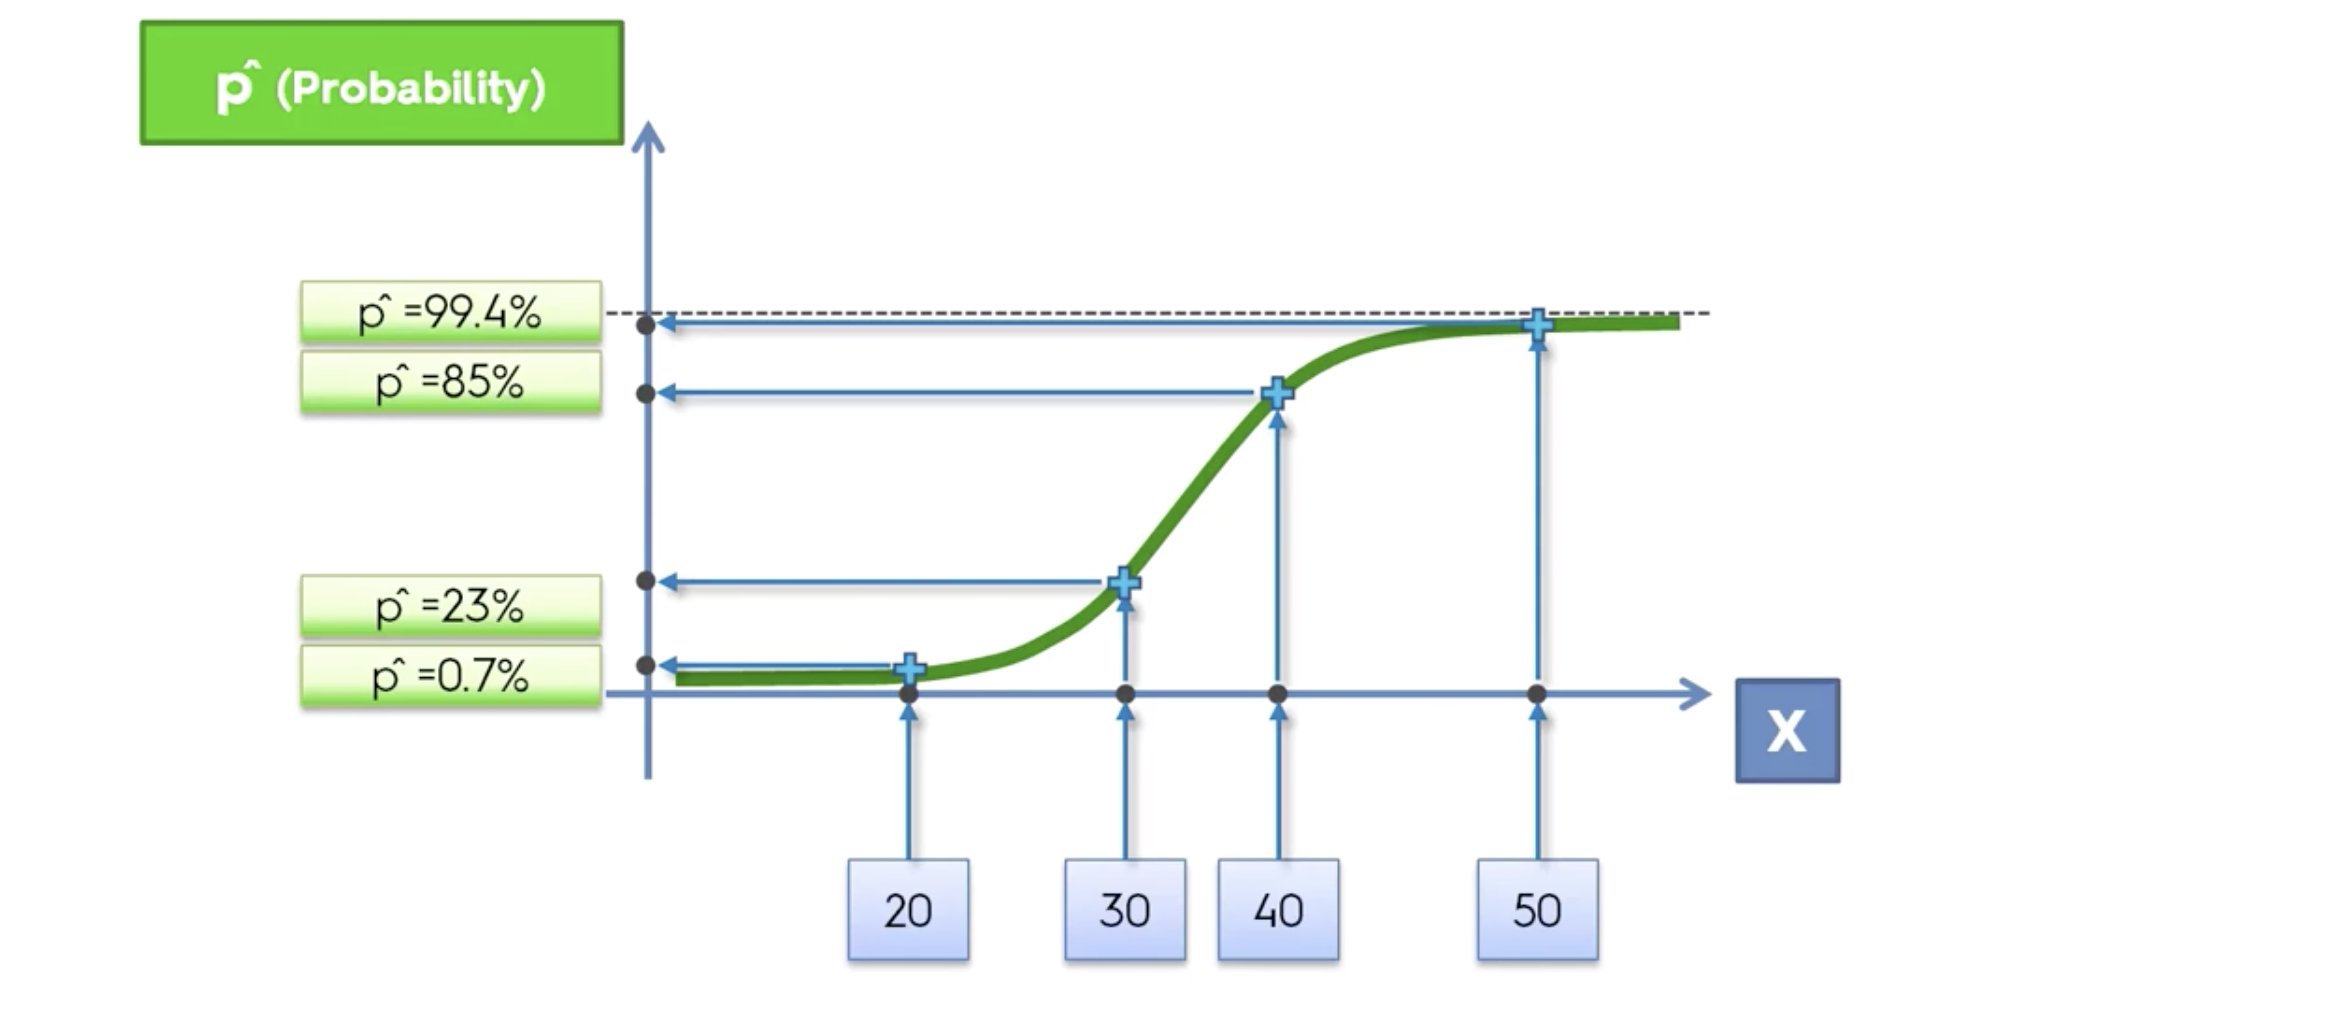

### 최종 예측값은, 0.5를 기준으로 두개의 부류로 나눈다. 그 값은 0 과 1 이다.

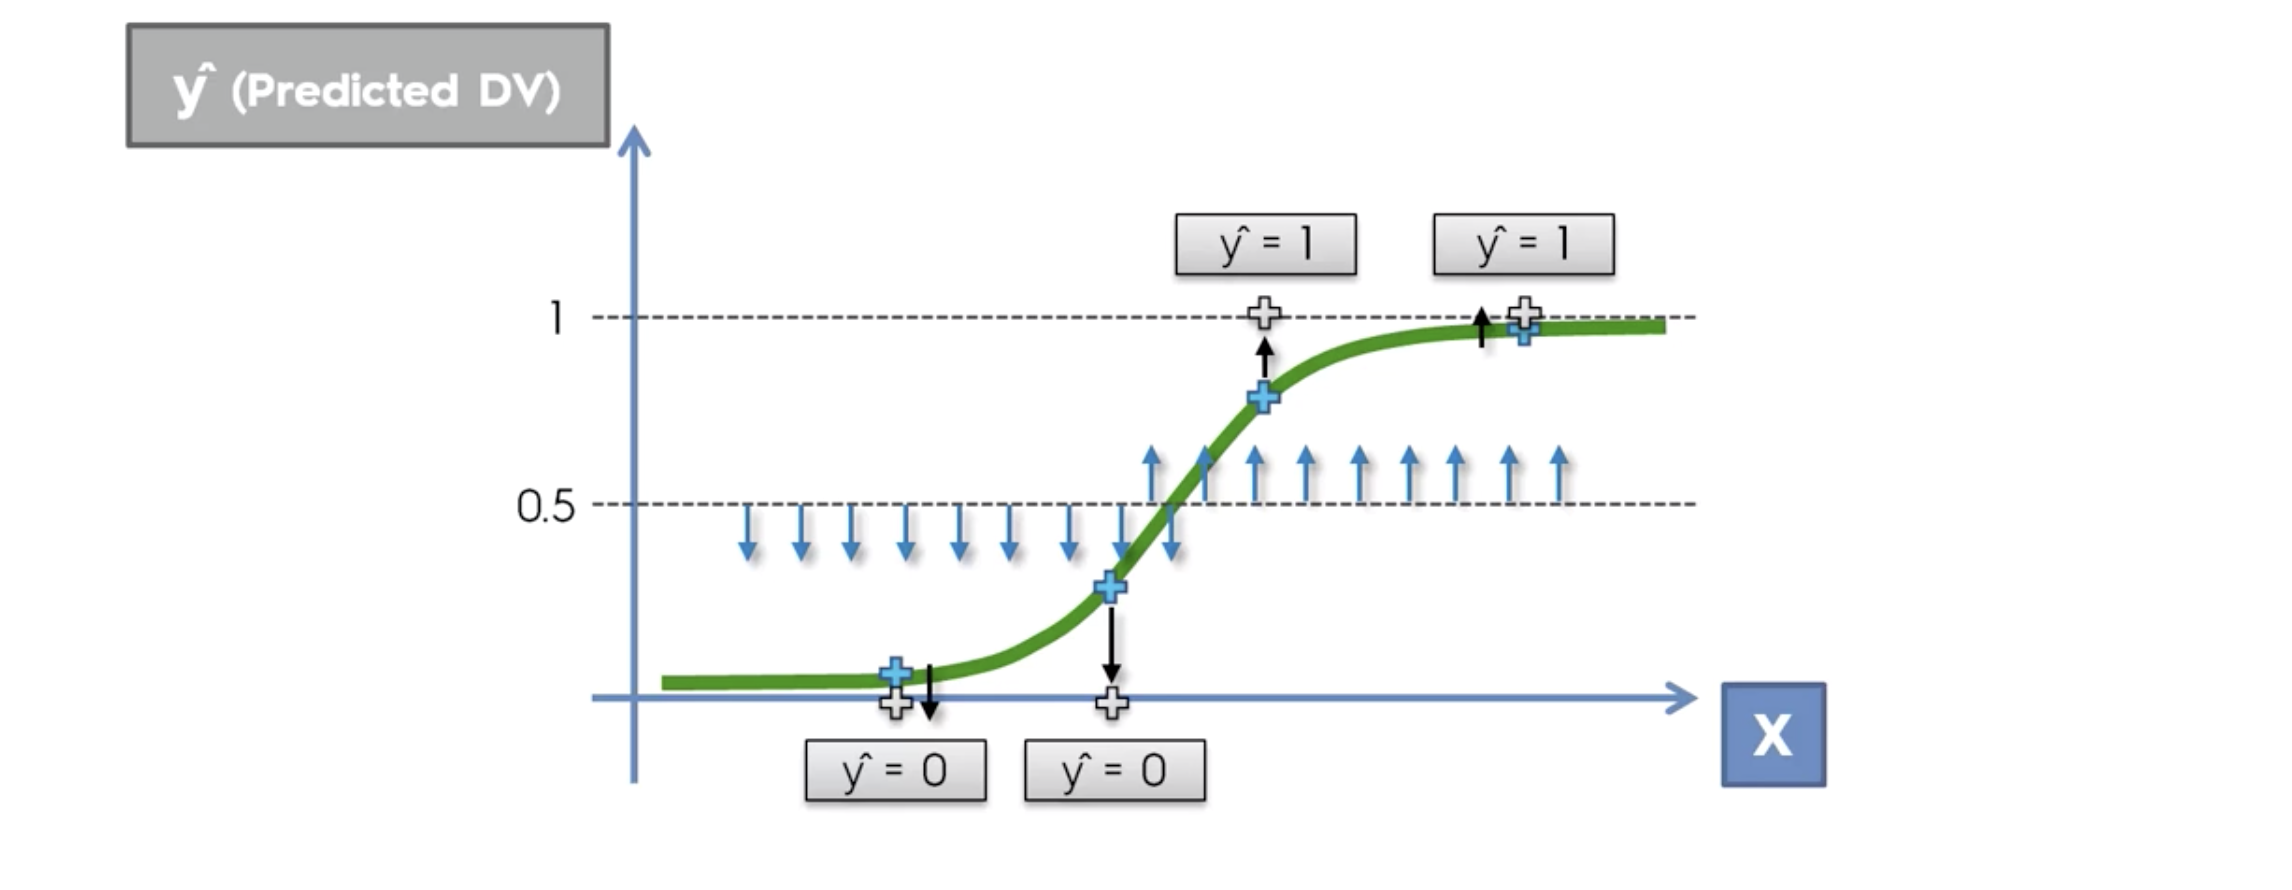

# lib와 데이터 로딩

In [1]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### 나이와 연봉으로 분석해서, 물건을 구매할지 안할지를 분류하자!!

- 어떤 고객이 구매할 가능성이 높은지 예측
- 고객 세분화 : 나이, 성별, 연봉에 따른 구매 패턴 분석
- 마케팅 타겟팅 : 구매 가능성 높은 고객군 식별

### 데이터 : 마케팅/광고 캠페인 반응 데이터
- User ID: 고객 ID
- Gender: 성별 (Male/Female)
- Age: 나이
- EstimatedSalary: 추정 연봉
- Purchased: 구매 여부 (0=구매 안 함, 1=구매함)

In [2]:
data_path = 'datas_ml/Social_Network_Ads.csv'
df = pd.read_csv(data_path)
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


In [4]:
df.isna().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [6]:
y = df['Purchased']

In [7]:
# 0 : 미구매, 1 : 구매
y.unique()

array([0, 1])

In [39]:
df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='str')

In [40]:
X = df[['User ID', 'Gender', 'Age', 'EstimatedSalary']]
X

,User ID,Gender,Age,EstimatedSalary
0,15624510,Male,19,19000
1,15810944,Male,35,20000
2,15668575,Female,26,43000
3,15603246,Female,27,57000
4,15804002,Male,19,76000
...,...,...,...,...
395,15691863,Female,46,41000
396,15706071,Male,51,23000
397,15654296,Female,50,20000
398,15755018,Male,36,33000


In [ ]:
# 독립변수 df.loc 로 분리하기
# 행/열의 이름을 사용하여 데이터를 읽어오는 방법
df.loc[:, ["User ID", "Gender", "Age", "EstimatedSalary"]]

,User ID,Gender,Age,EstimatedSalary
0,15624510,Male,19,19000
1,15810944,Male,35,20000
2,15668575,Female,26,43000
3,15603246,Female,27,57000
4,15804002,Male,19,76000
...,...,...,...,...
395,15691863,Female,46,41000
396,15706071,Male,51,23000
397,15654296,Female,50,20000
398,15755018,Male,36,33000


In [49]:
# 행/열의 위치를 기준으로 데이터를 선택하는 방법
X = df.iloc[:, 1:4] 

In [50]:
X['Gender'].nunique()

2

In [51]:
X['Gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [52]:
X['Gender'].value_counts()

Gender
Female    204
Male      196
Name: count, dtype: int64

In [44]:
def get_gender(gender):
    if gender == "Male":
        return 0
    else :
        return 1

In [53]:
# X['Gender'].apply(get_gender)
X['Gender'] = X['Gender'].apply(get_gender)

In [ ]:
X.head()
# 아래의 데이터의 경우 gender와 Age 의 경우 범위가 작기 때문에 
# x1w1 + x2w2 + x3w3 = hat{y} 인데 이 경우 x3 의 범위가 너무 커지면 영향력이 비대해지기 때문에 스케일링이 필요하다

,Gender,Age,EstimatedSalary
0,0,19,19000
1,0,35,20000
2,1,26,43000
3,1,27,57000
4,0,19,76000


In [55]:
X['Gender'].value_counts()

Gender
1    204
0    196
Name: count, dtype: int64

# Feature scaling

In [56]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [ ]:
# 표쥰정규 분포에 맞춰서 데이터를 스케일링을 수행한다.
X_scaler = StandardScaler()

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [ ]:
X_scaler.fit(X)
# fit()의 목적은 데이터를 보고 모델이나 전처리기가 필요한 값을 학습하는 것입니다.

StandardScaler()

In [65]:
X_scaler.transform(X)

array([[-1.02020406, -1.78179743, -1.49004624],
       [-1.02020406, -0.25358736, -1.46068138],
       [ 0.98019606, -1.11320552, -0.78528968],
       ...,
       [ 0.98019606,  1.17910958, -1.46068138],
       [-1.02020406, -0.15807423, -1.07893824],
       [ 0.98019606,  1.08359645, -0.99084367]], shape=(400, 3))

In [68]:
# x의 독립변수들의 데이터 특징을 파악해야 한다.
X_scaled = X_scaler.fit_transform(X)

# train, test 데이터 분할

In [71]:
from sklearn.model_selection import train_test_split
import pandas as pd

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=7)

In [ ]:
# 주어진 데이터의 행열의 크기가 일치하는지에 대해서 반드시 확인해야 한다. 일치하지 않은 경우에는 제대로된 학습이 이루어지지 않기 때문이다.
X_train.shape, y_train.shape

((300, 3), (300,))

In [75]:
X_test.shape, y_test.shape

((100, 3), (100,))

# 모델 학습

In [76]:
from sklearn.linear_model import LogisticRegression

In [77]:
# 빈 깡통 모델
classifier = LogisticRegression()

In [52]:
classifier.coef_

AttributeError: 'LogisticRegression' object has no attribute 'coef_'

In [82]:
# 학습
classifier.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [83]:
y_pred = classifier.predict(X_test)
y_pred

array([1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0])

In [ ]:
classifier.coef_
# w1, w2, w3 가중치에 해당
# y_pred = w1x1 + w2x2 + w3x3 에 해당하는 값이 결과로 나오고
# 이 결과가 시그모이드 함수에 전달이 되어서 계산이 된다.

array([[-0.06049657,  2.13723312,  1.17166628]])


```py
s * 2
s + 10
s > 20
np.sqrt(s)
```
Pandas는 NumPy 등의 벡터화 연산(vectorized operation)을 활용하기 때문에, 실제 반복 처리는 주로 C/Cython 수준에서 수행됩니다. 그래서 직접 Python for문을 작성하는 것보다 일반적으로 훨씬 빠릅니다.

```py
s.apply(lambda x: x * 2)
s.map(lambda x: x * 2)
```
는 함수가 각 원소에 대해 호출되는 형태이기 때문에 상대적으로 Python-level 반복에 가까워 성능이 떨어질 수 있습니다.

Series 연산은 보통 Series의 모든 원소에 대해 연산을 적용하지만, Python이 각 원소를 하나씩 for문으로 순회하는 것이 아니라 벡터화된 내부 연산으로 한꺼번에 처리한다고 이해하면 가장 정확합니다.

## 테스트 평가

In [84]:
# 정확도 계산
(y_test == y_pred).sum() / len(y_test) * 100

np.float64(86.0)

- 정확도 86%

In [ ]:
# 실제 1인데, 예측 1로 한것
# 실제 0인데, 예측 1으로 한것

# 실제 1인데, 예측 0으로 한것
# 실제 0인데, 예측 0으로 학것

# 이것을 컨퓨전 매트릭스(혼동행렬)
# 실제 나와야 하는 결과와 일치하는 경우, 일치하지 않는 경우를 구분하여 어떤 종류의 실패, 실수가 발생한 것인지에 대해서 시각화한 결과를 보여주는 것이다.

# 여기서 중요한 점은 혼동행렬 자체가 모델 성능을 하나의 숫자로 평가하는 것이 아니라, 어떤 종류의 실수를 얼마나 했는지 보여준다는 것입니다.

In [86]:
y_test.to_frame()

,Purchased
265,1
65,0
120,0
132,0
378,1
...,...
288,0
66,0
303,1
165,0


In [87]:
df_test = y_test.to_frame()
df_test['y_pred'] = y_pred
df_test

,Purchased,y_pred
265,1,1
65,0,0
120,0,0
132,0,0
378,1,1
...,...,...
288,0,1
66,0,0
303,1,0
165,0,0


# Confusion Matrix

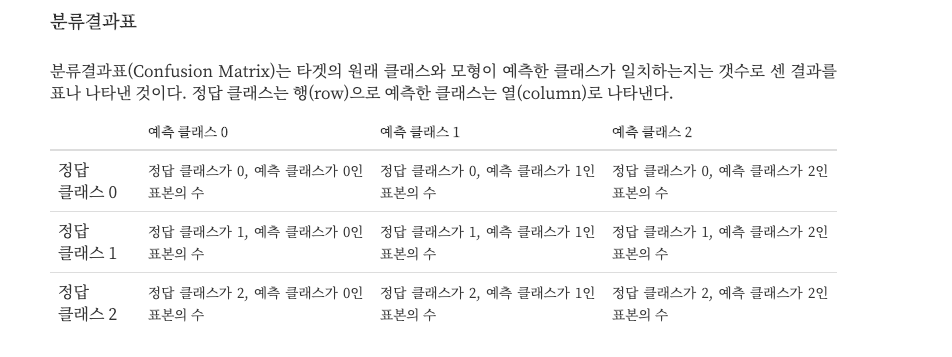

### 두 개의 클래스로 분류하는 경우는 아래와 같다.

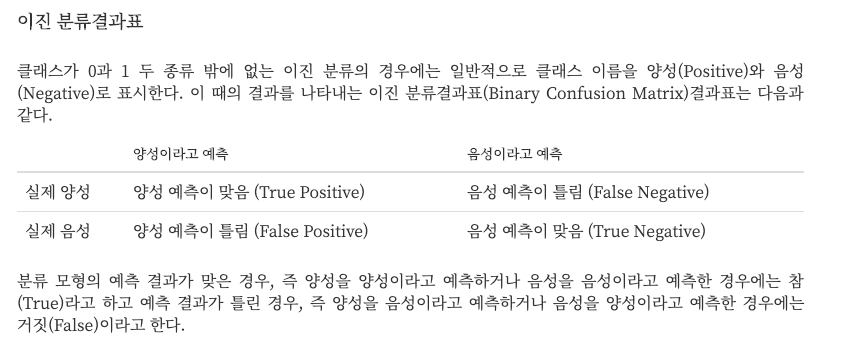

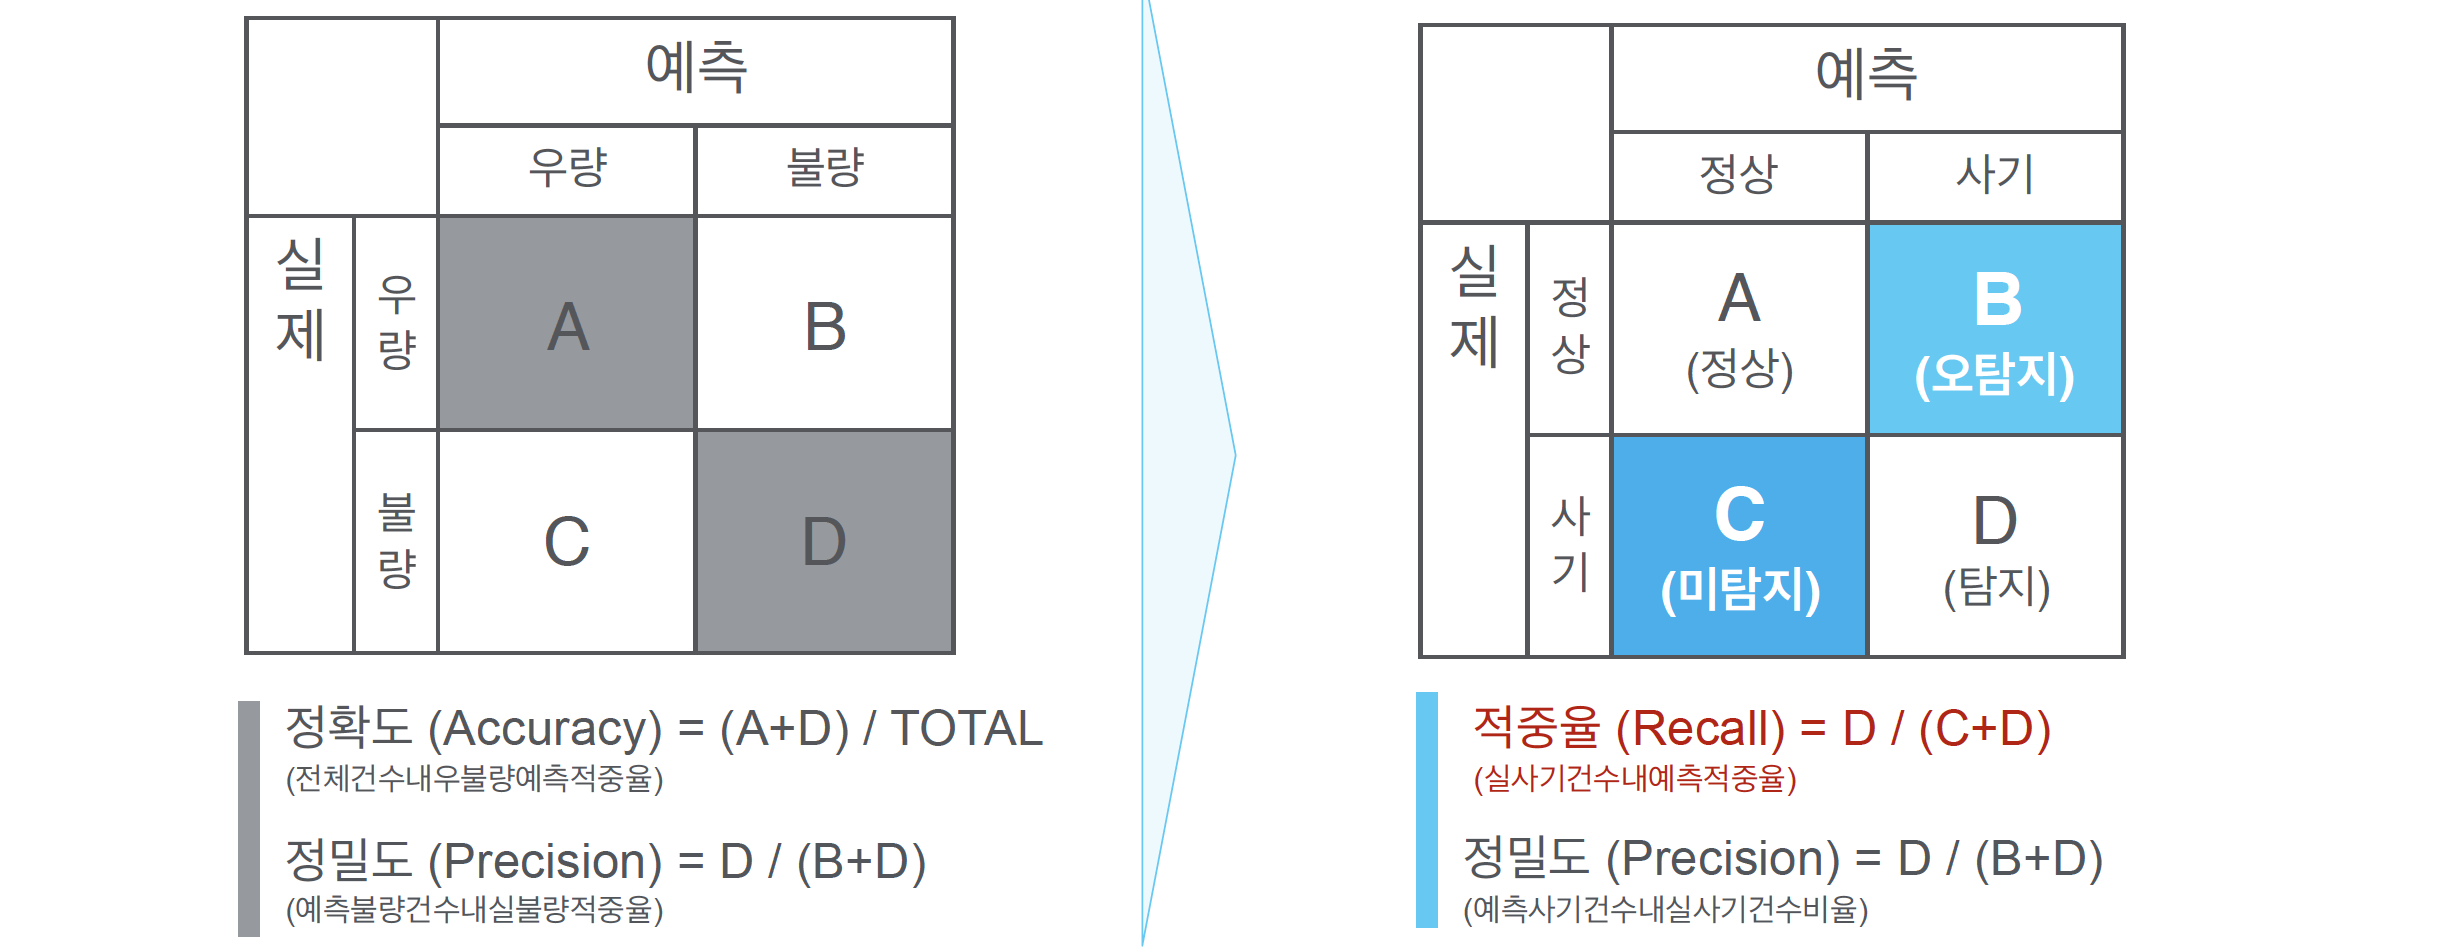

In [60]:
from sklearn.metrics import confusion_matrix

# confusion_matrix(실제값, 예측값)
confusion_matrix(y_test, y_pred)

array([[60,  8],
       [ 6, 26]])

In [61]:
cm = confusion_matrix(y_test, y_pred)

In [62]:
cm 

array([[60,  8],
       [ 6, 26]])

In [63]:
(60 + 26) / cm.sum()

np.float64(0.86)

## 정밀도, 재현율 한꺼번에 보기

In [64]:
from sklearn.metrics import classification_report, accuracy_score

# y_test: 실제 라벨, y_pred: 모델 예측 라벨
print("정확도:", accuracy_score(y_test, y_pred))
print("\n[정밀도, 재현율, F1-score 요약 보고서]")
print(classification_report(y_test, y_pred))

정확도: 0.86

[정밀도, 재현율, F1-score 요약 보고서]
              precision    recall  f1-score   support

           0       0.91      0.88      0.90        68
           1       0.76      0.81      0.79        32

    accuracy                           0.86       100
   macro avg       0.84      0.85      0.84       100
weighted avg       0.86      0.86      0.86       100



## 모델 결과를 보고 전략을 짠다

In [65]:
import seaborn as sb

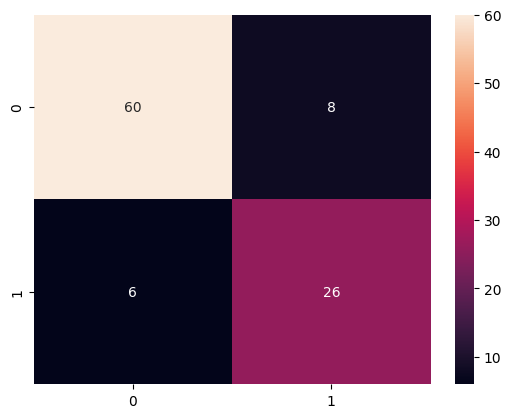

In [66]:
sb.heatmap(data=cm, annot=True)
plt.show()

- 구매를 할지 안할지 예측함
- 여기서, 정밀도, 재현율 중 어느것을 더 중요하게 생각하고, 성능을 높여야 할까?

- 우선적으로 

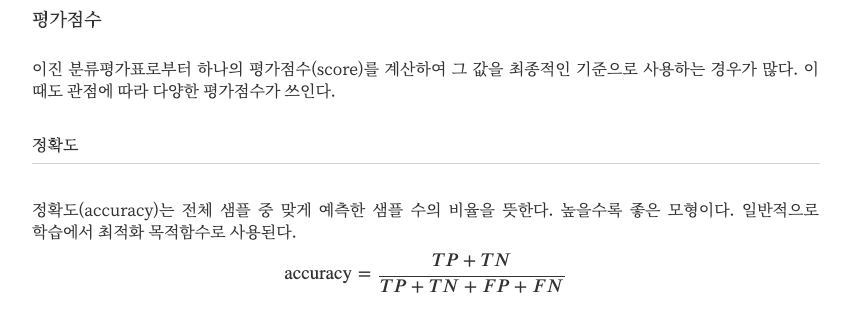

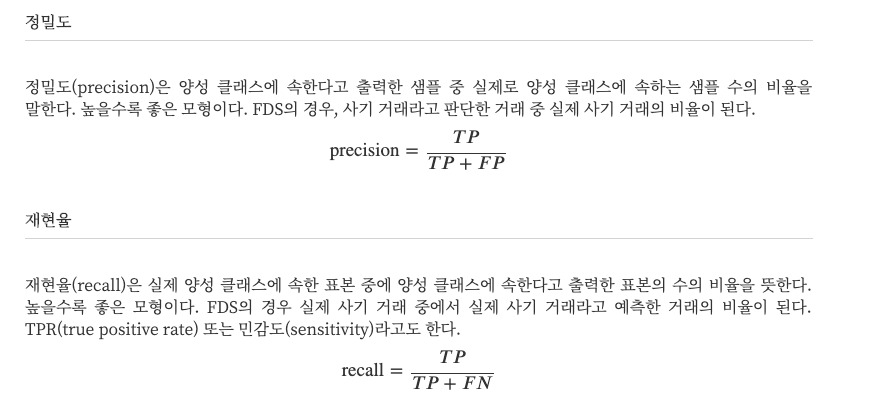

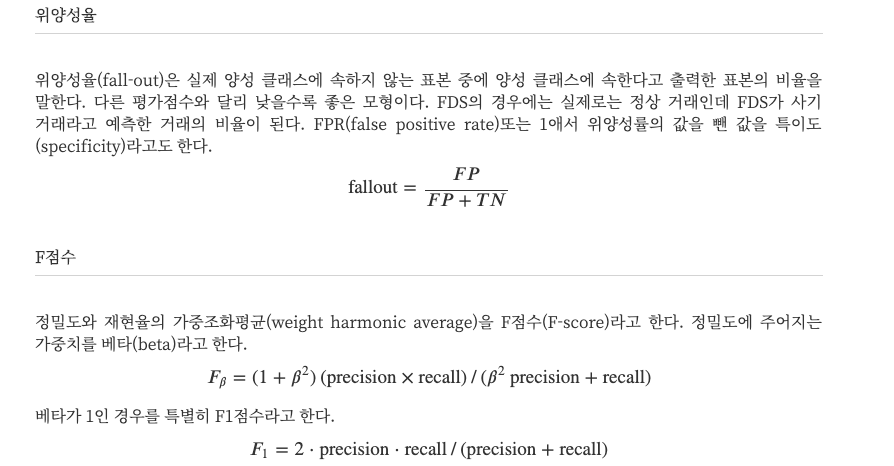

## Gender를 고정값으로 설정

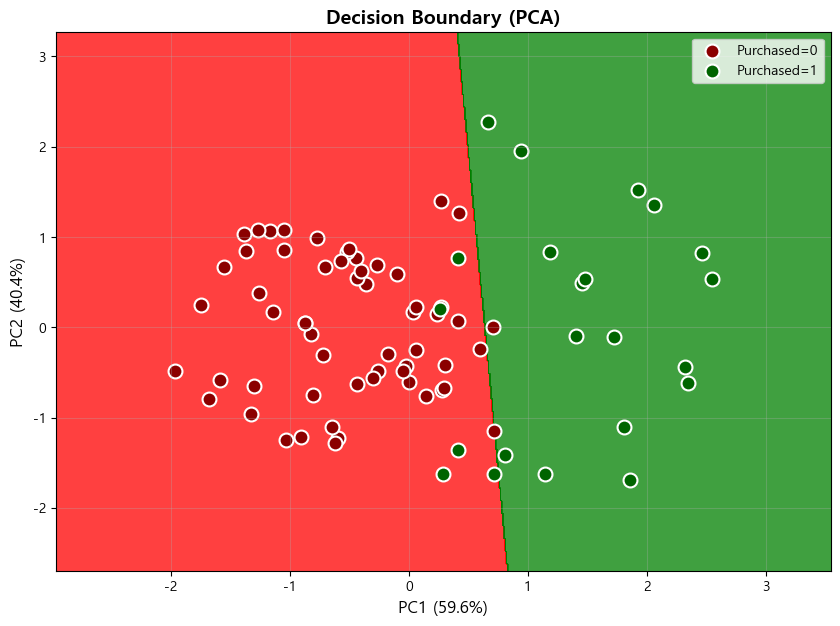

In [75]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

# 3D → 2D 차원 축소
pca = PCA(n_components=2)
X_test_2d = pca.fit_transform(X_test)

# 2D meshgrid
X1, X2 = np.meshgrid(
    np.arange(X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1, 0.01),
    np.arange(X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1, 0.01)
)

# 원래 3D 공간으로 역변환 후 예측
X_grid_2d = np.c_[X1.ravel(), X2.ravel()]
X_grid_3d = pca.inverse_transform(X_grid_2d)
predictions = classifier.predict(X_grid_3d).reshape(X1.shape)

# 시각화
plt.figure(figsize=(10, 7))
plt.contourf(X1, X2, predictions,
             alpha=0.75, cmap=ListedColormap(('red', 'green')))

for i, j in enumerate([0, 1]):
    plt.scatter(X_test_2d[y_test == j, 0], 
               X_test_2d[y_test == j, 1],
               c='darkred' if j == 0 else 'darkgreen',
               label=f'Purchased={j}',
               edgecolors='white',
               s=100,
               linewidth=1.5)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
plt.title('Decision Boundary (PCA)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()